In [5]:
import os
from scipy.signal import spectrogram 
from scipy.io import wavfile
import numpy as np
from PIL import Image
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

In [11]:
# Function to visualize raw waveform data
def plot_waveform(file_path, title=None):
    """
    Plot the raw waveform of an audio file.
    
    Parameters:
        file_path (str): Path to the audio file
        title (str): Title for the plot
    """
    fs, x = wavfile.read(file_path)
    duration = len(x) / fs
    time = np.arange(len(x)) / fs
    
    plt.figure(figsize=(14, 5))
    plt.plot(time, x, linewidth=0.5)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(title or f'Waveform: {os.path.basename(file_path)}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Sample Rate: {fs} Hz")
    print(f"Duration: {duration:.2f} seconds")
    print(f"Total Samples: {len(x)}")
    print(f"Amplitude Range: [{x.min()}, {x.max()}]")


def plot_waveform_segmented(file_path, segment_duration=1.0, max_segments=4):
    """
    Plot the waveform in segments (useful for long audio files).
    
    Parameters:
        file_path (str): Path to the audio file
        segment_duration (float): Duration of each segment in seconds
        max_segments (int): Maximum number of segments to display
    """
    fs, x = wavfile.read(file_path)
    duration = len(x) / fs
    samples_per_segment = int(segment_duration * fs)
    
    num_segments = min(int(len(x) / samples_per_segment), max_segments)
    
    fig, axes = plt.subplots(num_segments, 1, figsize=(14, 3*num_segments))
    if num_segments == 1:
        axes = [axes]
    
    for i in range(num_segments):
        start_sample = i * samples_per_segment
        end_sample = min(start_sample + samples_per_segment, len(x))
        segment = x[start_sample:end_sample]
        time_segment = np.arange(start_sample, end_sample) / fs
        
        axes[i].plot(time_segment, segment, linewidth=0.8, color='steelblue')
        axes[i].set_ylabel('Amplitude')
        axes[i].set_title(f'Segment {i+1} ({segment_duration:.1f}s)')
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'Segmented Waveform: {os.path.basename(file_path)}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Total Duration: {duration:.2f} seconds")
    print(f"Displayed {num_segments} segments of {segment_duration:.1f}s each")


def plot_waveform_with_stats(file_path):
    """
    Plot waveform along with statistical information (RMS, peak, zero-crossings).
    
    Parameters:
        file_path (str): Path to the audio file
    """
    fs, x = wavfile.read(file_path)
    duration = len(x) / fs
    time = np.arange(len(x)) / fs
    
    # Calculate audio statistics
    rms = np.sqrt(np.mean(x**2))
    peak = np.max(np.abs(x))
    zero_crossings = np.sum(np.abs(np.diff(np.sign(x)))) // 2
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Main waveform plot
    ax1.plot(time, x, linewidth=0.5, color='steelblue')
    ax1.axhline(rms, color='red', linestyle='--', label=f'RMS: {rms:.2f}')
    ax1.axhline(-rms, color='red', linestyle='--')
    ax1.axhline(peak, color='green', linestyle='--', label=f'Peak: {peak:.2f}')
    ax1.axhline(-peak, color='green', linestyle='--')
    ax1.set_ylabel('Amplitude')
    ax1.set_title(f'Waveform with RMS and Peak: {os.path.basename(file_path)}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Amplitude histogram
    ax2.hist(x, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Amplitude')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Amplitude Distribution')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n=== Audio Statistics ===")
    print(f"Sample Rate: {fs} Hz")
    print(f"Duration: {duration:.2f} seconds")
    print(f"RMS (Energy): {rms:.4f}")
    print(f"Peak Amplitude: {peak:.4f}")
    print(f"Zero Crossings: {zero_crossings}")
    print(f"Bit Depth: {np.iinfo(x.dtype).bits} bits")


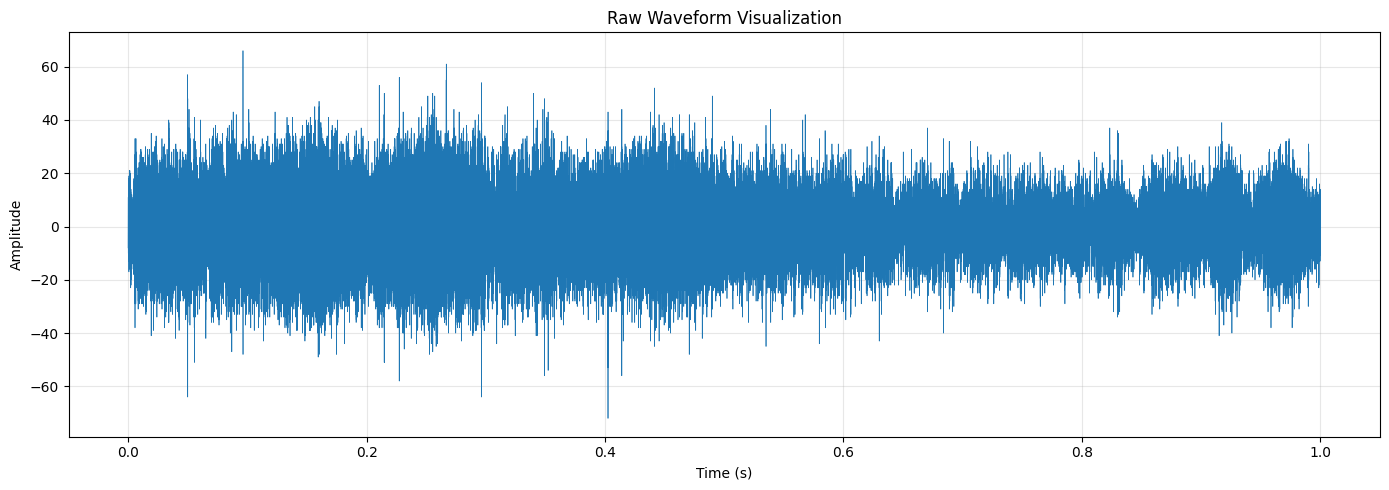

Sample Rate: 96000 Hz
Duration: 1.00 seconds
Total Samples: 96000
Amplitude Range: [-72, 66]


In [12]:
# EXAMPLE 1: Simple waveform visualization
# Change this path to any audio file you want to visualize
audio_file = r"C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\1_9.wav"
plot_waveform(audio_file, title="Raw Waveform Visualization")


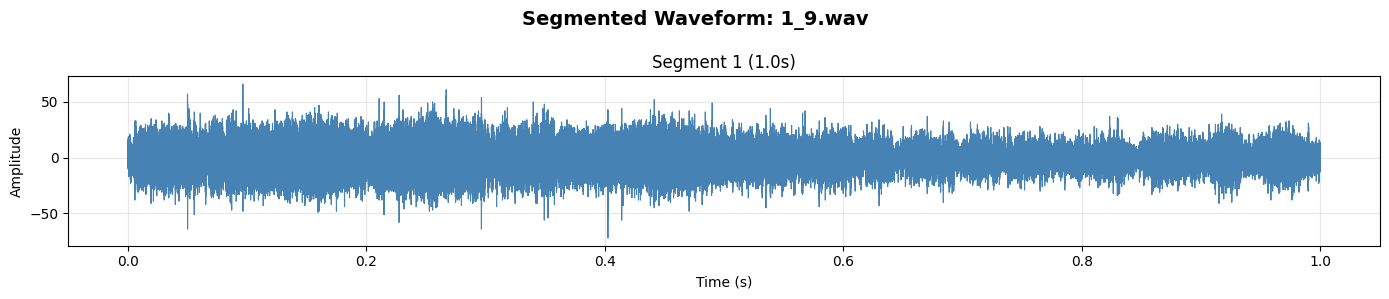

Total Duration: 1.00 seconds
Displayed 1 segments of 1.0s each


In [13]:
# EXAMPLE 2: Segmented view (useful for long files - shows first 4 segments)
plot_waveform_segmented(audio_file, segment_duration=1.0, max_segments=4)


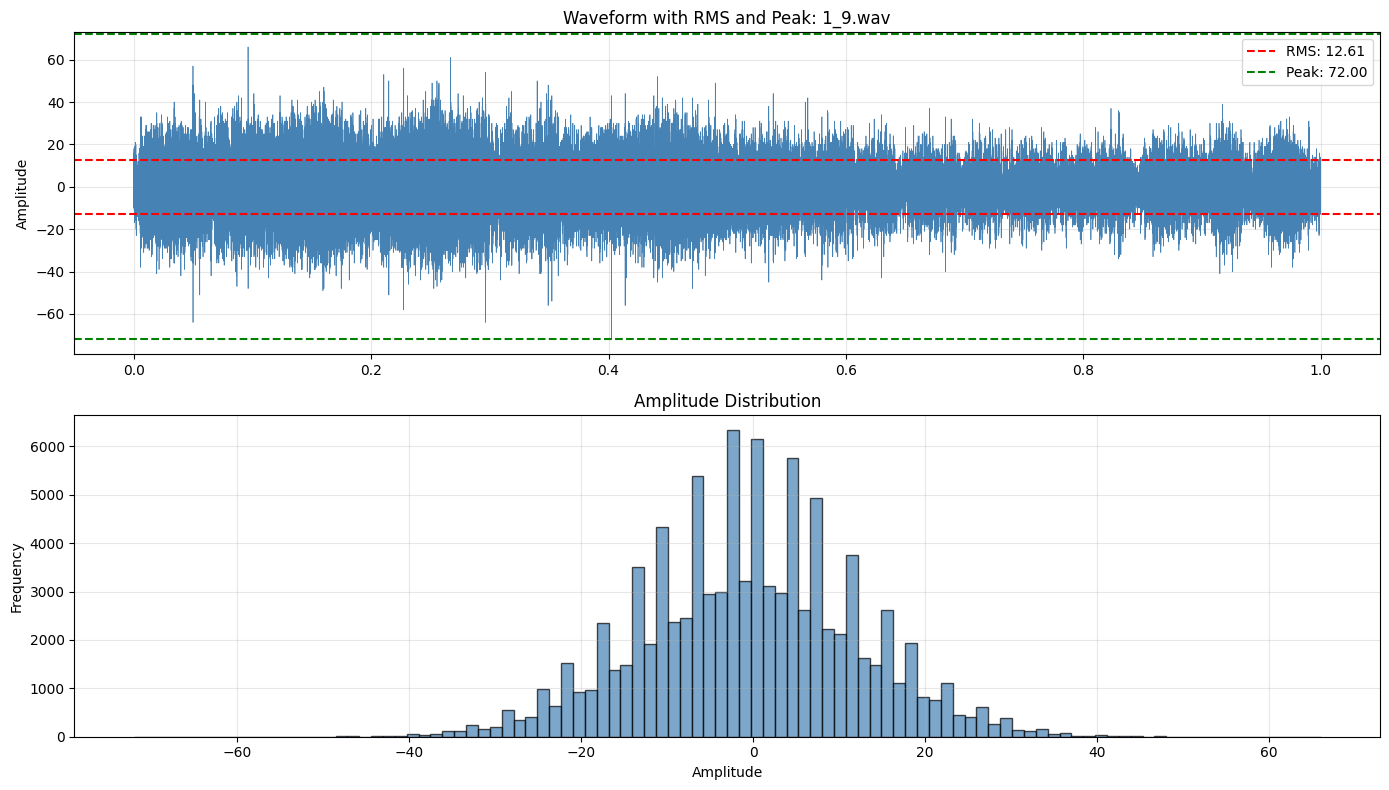


=== Audio Statistics ===
Sample Rate: 96000 Hz
Duration: 1.00 seconds
RMS (Energy): 12.6126
Peak Amplitude: 72.0000
Zero Crossings: 23326
Bit Depth: 16 bits


In [14]:
# EXAMPLE 3: Waveform with audio statistics (RMS, Peak, Zero-crossings)
plot_waveform_with_stats(audio_file)


In [15]:
# BONUS: Function to compare multiple waveforms side-by-side
def plot_waveform_comparison(file_paths, titles=None):
    """
    Compare waveforms from multiple audio files side-by-side.
    
    Parameters:
        file_paths (list): List of paths to audio files
        titles (list): Optional list of titles for each subplot
    """
    num_files = len(file_paths)
    fig, axes = plt.subplots(num_files, 1, figsize=(14, 3*num_files))
    
    if num_files == 1:
        axes = [axes]
    
    for idx, file_path in enumerate(file_paths):
        fs, x = wavfile.read(file_path)
        time = np.arange(len(x)) / fs
        
        axes[idx].plot(time, x, linewidth=0.5, color='steelblue')
        axes[idx].set_ylabel('Amplitude')
        title = titles[idx] if titles else os.path.basename(file_path)
        axes[idx].set_title(title)
        axes[idx].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()


# EXAMPLE 4: OPTIONAL - Compare waveforms from different categories
# Uncomment and modify paths to compare boat vs whale sounds
# boat_file = r"C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\...\some_boat.wav"
# whale_file = r"C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\some_whale.wav"
# plot_waveform_comparison([boat_file, whale_file], titles=["Boat Audio", "Whale Audio"])


In [24]:
#Does not need to run each time 
#parameters for the split audio function 
input_file =r"C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\noise_target数据集\noise_target数据集\noise_未切分\DATA0001\DATA0033.wav"
output_dir='NoiseFragments2'
os.makedirs(output_dir, exist_ok=True)
chunk_duration=3
startingfilenumber=100


In [25]:
#Does not need to run eah time 
#Function Def for turning larger audio files into smaller 3 second fragments 
import os
import numpy as np
import librosa
import soundfile as sf

def split_audio_into_chunks(input_file, output_dir, chunk_duration=3,startingfilenumber=0):
    os.makedirs(output_dir, exist_ok=True)
    
    # Load audio file
    y, sr = librosa.load(input_file, sr=None)  # keep original sample rate
    
    chunk_samples = chunk_duration * sr
    total_samples = len(y)
    
    num_chunks = total_samples // chunk_samples
    
    for i in range(num_chunks):
        start = i * chunk_samples
        end = start + chunk_samples
        chunk = y[start:end]
        
        output_path = os.path.join(output_dir, f"chunk_{startingfilenumber:04d}.wav")
        sf.write(output_path, chunk, sr)
        startingfilenumber+=1
       
    
    print(f"Saved {num_chunks} chunks to {output_dir}")



In [26]:
#Does not need to run each time 
#Usage for the split_audio function 
split_audio_into_chunks(input_file, output_dir, chunk_duration,startingfilenumber)

Saved 100 chunks to NoiseFragments2


In [ ]:
#Block of code for augmenting the 3 second noise chunks to create more training data for the model.
#There are 5 varitatioons of augmentations but we ramdomize the chance of each happening and limit to 3 to create more variety in the augmented data.
import audiomentations as A
import librosa
import soundfile as sf
import os

# Define augmentation pipeline
augment = A.Compose([
    A.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),  # Subtle background noise
    A.TimeStretch(min_rate=0.9, max_rate=1.1, p=0.5),  # Slight speed changes
    A.PitchShift(min_semitones=-1, max_semitones=1, p=0.5),  # Minor pitch shifts
    A.Shift(min_shift=-0.2, max_shift=0.2, p=0.5),  # Time shifts (in seconds)
    A.Gain(min_gain_db=-3, max_gain_db=3, p=0.5)  # Volume adjustments
])

# Paths
noise_folder = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\NoiseFragments2"  # Folder with your 3-sec noise WAVs
augmented_output = "NoiseFragments2_Augmented"  # New folder for augmented files
os.makedirs(augmented_output, exist_ok=True)


# Augment each file 
for file in os.listdir(noise_folder):
    if file.endswith('.wav'):
        file_path = os.path.join(noise_folder, file)
        y, sr = librosa.load(file_path, sr=None)
        
        # Generate 3 augmented versions per original
        for i in range(3):
            y_aug = augment(y, sample_rate=sr)
            aug_file = os.path.join(augmented_output, f"{os.path.splitext(file)[0]}_aug{i}.wav")
            sf.write(aug_file, y_aug, sr)

print("Augmentation complete!")

Augmentation complete!


In [31]:
#Does not need to run each time
#function for combining folder files into one
import os
import shutil

def combine_folders(source_folders, destination_folder, move_files=False):
    """
    Combines contents of multiple folders into a single folder.
    
    Parameters:
        source_folders (list): List of folder paths to combine
        destination_folder (str): Target folder path
        move_files (bool): If True, moves files. If False, copies files.
    """
    
    os.makedirs(destination_folder, exist_ok=True)
    
    for folder in source_folders:
        for root, _, files in os.walk(folder):
            for file in files:
                source_path = os.path.join(root, file)
                
                # Handle duplicate filenames
                base_name = file
                name, ext = os.path.splitext(base_name)
                counter = 1
                dest_path = os.path.join(destination_folder, base_name)
                
                while os.path.exists(dest_path):
                    new_name = f"{name}_{counter}{ext}"
                    dest_path = os.path.join(destination_folder, new_name)
                    counter += 1
                
                if move_files:
                    shutil.move(source_path, dest_path)
                else:
                    shutil.copy2(source_path, dest_path)

    print("Done combining folders.")


In [33]:
#Does not need to run each time 
#using combin_folders function
source_dirs = [
    r"C:\Users\yusle\OneDrive\Desktop\boat_audio\NoiseFragments1",
    r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\NoiseFragments1_Augmented",
    r"C:\Users\yusle\OneDrive\Desktop\boat_audio\NoiseFragments2",
    r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\NoiseFragments2_Augmented"
]

combine_folders(source_dirs, "combined_noise", move_files=False)


Done combining folders.


In [8]:
audio_folder=r'C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other'
output_folder='4_spec'
os.makedirs(output_folder, exist_ok=True)

In [2]:
# We need to create parmeters for the spectrogram
freq_min=10
freq_max=10000
window_size=1024
overlapp=800
n_fft=1024*4  #2^10

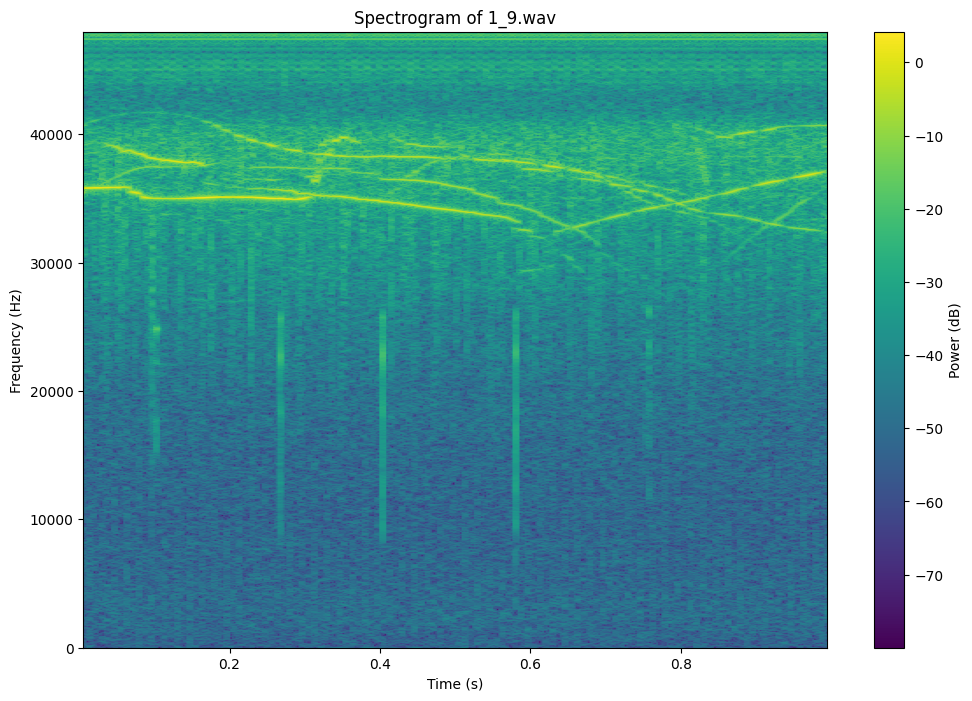

The frequency with the highest average power (most noticeable) is 12914.06 Hz


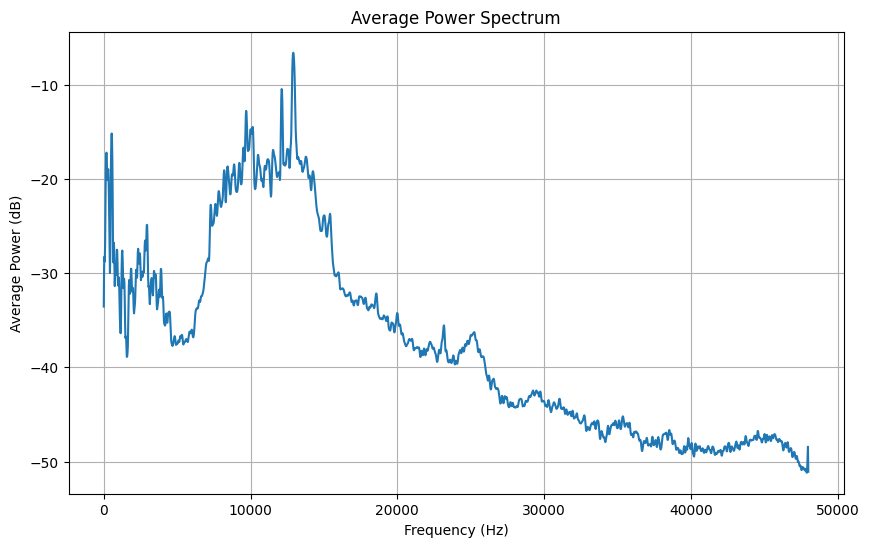

In [ ]:
# Code for testing a single audio file: generate spectrogram, display it, and find the frequency with highest average power

import matplotlib.pyplot as plt

# Set the path to your single audio file
file_path = r"C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\1_9.wav"  # Example path, change as needed

# Read the audio file
fs, x = wavfile.read(file_path)

# Compute the spectrogram
f, t, S = spectrogram(x, fs, nperseg=window_size, noverlap=overlapp, nfft=n_fft)

# Use full frequency range (no mask)
sxx = S

# Convert to dB
G = 10 * np.log10(sxx + 1e-8)

# Flip for display (high freq at top)
G_flipped = np.flipud(G)

# Display the spectrogram
plt.figure(figsize=(12, 8))
plt.imshow(G_flipped, aspect='auto', origin='lower', extent=[t.min(), t.max(), f.min(), f.max()])
plt.colorbar(label='Power (dB)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Spectrogram of ' + os.path.basename(file_path))
plt.show()

# Analyze the average power per frequency to find the most prominent frequency
avg_power = np.mean(sxx, axis=1)  # Average over time for each frequency bin
max_idx = np.argmax(avg_power)
prominent_freq = f[max_idx]

print(f"The frequency with the highest average power (most noticeable) is {prominent_freq:.2f} Hz")

# Optionally, plot the average power spectrum
plt.figure(figsize=(10, 6))
plt.plot(f, 10 * np.log10(avg_power + 1e-8))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Average Power (dB)')
plt.title('Average Power Spectrum')
plt.grid(True)
plt.show()

In [ ]:
#loop for turning audio files in the directed folder into spectrogram with a mask and then normilzing it and saving the image to the output folder
for file in os.listdir(audio_folder):
    file_path= os.path.join(audio_folder,file)
    print(file_path)
    fs,x=wavfile.read(file_path)
    f,t,S=spectrogram(x,fs,nperseg=window_size,noverlap=overlapp,nfft=n_fft)
    f_mask=(f>=freq_min)&(f<=freq_max)
    sxx=S[f_mask,:]
    G=10*np.log10(sxx+1e-8)
    G=np.flipud(G)
    # normalize the spectrogram
    norm=Normalize(vmin=np.min(G),vmax=np.max(G))
    G_normalized=norm(G)
    # convert spectrogram to image
    G_colormap=plt.cm.jet( G_normalized)
    G_image=( G_colormap[:,:,:3]*255).astype(np.uint8)
    G_resized=Image.fromarray(G_image).resize((224,224))
    output_file=os.path.join(output_folder,os.path.basename(file_path).replace('.wav','.png'))
    G_resized.save(  output_file)
    
        
    

C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0000.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0001.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0002.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0003.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0004.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0005.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0006.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0007.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0008.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0009.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositori

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [10]:
#loop for turning audio files in the directed folder into spectrogram (without) a mask and then normilzing it and saving the image to the output folder
for file in os.listdir(audio_folder):
    file_path= os.path.join(audio_folder,file)
    print(file_path)
    fs,x=wavfile.read(file_path)
    f,t,S=spectrogram(x,fs,nperseg=window_size,noverlap=overlapp,nfft=n_fft)
    sxx=S
    G=10*np.log10(sxx+1e-8)
    G=np.flipud(G)
    # normalize the spectrogram
    norm=Normalize(vmin=np.min(G),vmax=np.max(G))
    G_normalized=norm(G)
    # convert spectrogram to image
    G_colormap=plt.cm.jet( G_normalized)
    G_image=( G_colormap[:,:,:3]*255).astype(np.uint8)
    G_resized=Image.fromarray(G_image).resize((224,224))
    output_file=os.path.join(output_folder,os.path.basename(file_path).replace('.wav','.png'))
    G_resized.save(  output_file)
    
        
    

C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__10.wav
C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__11.wav
C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__12.wav
C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__13.wav
C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__14.wav
C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__15.wav
C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__16.wav
C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__17.wav
C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\other\20220624110853_S_No7_F_W_0_label__0__18.wav
C:\Users\y

In [2]:
# create model for training
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

## ImageNet Normalization

ImageNet normalization is crucial for pre-trained models (ViT, EfficientNet, ResNet).

**Why normalize?**
- Pre-trained models expect input in a specific statistical distribution
- Mean and Std are computed from the ImageNet dataset:
  - **Mean**: [0.485, 0.456, 0.406] (RGB channels)
  - **Std**: [0.229, 0.224, 0.225] (RGB channels)
- Without normalization, model predictions will be poor

**Formula**: `normalized_pixel = (pixel_value - mean) / std`

**Applied at:**
1. ✅ Training: `transform` in data loading
2. ✅ Validation: Same `transform`
3. ✅ Inference: Must use identical `transform_inference`

⚠️ **CRITICAL**: Always use the same normalization for training AND inference!

In [ ]:
# Utility functions for normalization
def get_imagenet_transform(normalize=True):
    """
    Get image transform with optional ImageNet normalization.
    
    Parameters:
        normalize (bool): If True, applies ImageNet normalization
    
    Returns:
        Composed transform
    """
    if normalize:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([transforms.ToTensor()])


def denormalize_batch(tensor_batch):
    """
    Denormalize ImageNet-normalized tensor batch for visualization.
    
    Parameters:
        tensor_batch: Batch of normalized tensors (B, C, H, W)
    
    Returns:
        Denormalized tensors clipped to [0, 1]
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    
    denorm = tensor_batch * std + mean
    return torch.clamp(denorm, 0, 1)


def apply_imagenet_norm_to_image(image_path, device):
    """
    Load image, apply ImageNet normalization, and prepare for model input.
    
    Parameters:
        image_path (str): Path to image file
        device: torch device (cuda or cpu)
    
    Returns:
        Normalized tensor ready for model input (1, 3, H, W)
    """
    transform = get_imagenet_transform(normalize=True)
    image = Image.open(image_path).convert("RGB")
    normalized = transform(image).unsqueeze(0).to(device)
    return normalized


# Verify ImageNet normalization is active
print("✅ ImageNet Normalization utilities loaded")
print("   Mean: [0.485, 0.456, 0.406]")
print("   Std:  [0.229, 0.224, 0.225]")

✅ ImageNet Normalization utilities loaded
   Mean: [0.485, 0.456, 0.406]
   Std:  [0.229, 0.224, 0.225]


In [20]:
#for splitting folder with subfolder classes into folder with train and validation 70/30 split folder and each having all the subfolder classes  
import os
import shutil
import random

# ===== CONFIG =====
source_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec"   # folder with class subfolders
train_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec_split\Train"
test_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec_split\Val"
split_ratio = 0.7
random_seed = 42
# ==================

random.seed(random_seed)

# Create Train and Test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Loop over each class folder
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Create class folders in Train and Test
    train_class_dir = os.path.join(train_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # Get all image files
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.shuffle(images)

    split_index = int(len(images) * split_ratio)
    train_images = images[:split_index]
    test_images = images[split_index:]

    # Copy files
    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(train_class_dir, img)
        )

    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(test_class_dir, img)
        )

    print(f"{class_name}: {len(train_images)} train / {len(test_images)} test")

print("✅ Dataset split complete.")


1_spec: 1866 train / 801 test
2_spec: 560 train / 240 test
3_spec: 2617 train / 1122 test
4_spec: 631 train / 271 test
✅ Dataset split complete.


In [5]:
#for splitting folder with subfolder classes into folder with train, validation, and test 70/15/15 split folder and each having all the subfolder classes  
import os
import shutil
import random

# ===== CONFIG =====
source_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec"   # folder with class subfolders
train_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec_split_better\Train"
val_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec_split_better\Val"
test_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec_split_better\Test"
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
random_seed = 42
# ==================

random.seed(random_seed)

# Create Train, Val, and Test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Loop over each class folder
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Create class folders in Train, Val, and Test
    train_class_dir = os.path.join(train_dir, class_name)
    val_class_dir = os.path.join(val_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # Get all image files
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.shuffle(images)

    # Calculate split indices
    train_index = int(len(images) * train_ratio)
    val_index = train_index + int(len(images) * val_ratio)
    
    train_images = images[:train_index]
    val_images = images[train_index:val_index]
    test_images = images[val_index:]

    # Copy files to Train folder
    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(train_class_dir, img)
        )

    # Copy files to Val folder
    for img in val_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(val_class_dir, img)
        )

    # Copy files to Test folder
    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(test_class_dir, img)
        )

    print(f"{class_name}: {len(train_images)} train / {len(val_images)} val / {len(test_images)} test")

print("✅ Dataset split complete (70/15/15).")

1_spec: 1866 train / 400 val / 401 test
2_spec: 560 train / 120 val / 120 test
3_spec: 2617 train / 560 val / 562 test
4_spec: 631 train / 135 val / 136 test
✅ Dataset split complete (70/15/15).


In [ ]:
# prepare data
data_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\boatFullSpec_split_better"  # Replace with your folder path
# Hyperparameters
batch_size = 16
num_epochs = 20
learning_rate = 0.001
num_classes =4  # Number of subfolders-(each folder is a class)
print(num_classes)

# Image transformations with ImageNet normalization (tested recently and not in model implementation)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

4


In [1]:
# Load dataset
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "Train"), transform=transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "Val"), transform=transform)


NameError: name 'datasets' is not defined

In [6]:

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [7]:
class ViTModel(nn.Module):
    def __init__(self, num_classes):
        super(ViTModel, self).__init__()
        # Load pretrained Vision Transformer model
        self.model = models.vit_b_16(pretrained=True)
        
        # Replace the head (classification layer)
        in_features = self.model.heads.head.in_features  # Get input features of the head
        self.model.heads.head = nn.Linear(in_features, num_classes)  # Replace with new classification layer

    def forward(self, x):
        return self.model(x)

In [8]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 3070


In [9]:
class ResNet18Model(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18Model, self).__init__()
        
        self.model = models.resnet18(pretrained=True)
        
        # Replace final fully connected layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [12]:
class ResNet50Model(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Model, self).__init__()
        
        self.model = models.resnet50(pretrained=True)
        
        # Replace final fully connected layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [13]:
#declaring the efficentNetModel structure 
class EfficientNetModel(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetModel, self).__init__()
        self.model = models.efficientnet_b0(pretrained=True)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [11]:
class EfficientNetModel_Mine(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=True)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(p=0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [29]:
#declaring the efficentNetModel b0 structure 
class EfficientNetModel(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetModel, self).__init__()
        self.model = models.efficientnet_b0(pretrained=True)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [ ]:
# ========== VARIANT 1: OPTIMIZED (Balanced Regularization) ==========
# Best for: Preventing overfitting, smoother training, consistent per-class performance
class EfficientNetModel_V1_Optimized(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=True)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),  # Moderate initial dropout
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.2),  # Gradual decrease
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.1),  # Light final dropout
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
# ========== VARIANT 2: ENHANCED (Higher Capacity) ==========
# Best for: More complex feature learning, larger models, better differentiation
class EfficientNetModel_V2_Enhanced(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=True)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)


## Model Variants Comparison

### **Variant 1: V1_Optimized** (Recommended to try first)
- **Hidden layers**: 512 → 256
- **Dropout strategy**: 0.3 → 0.2 → 0.1 (gradual)
- **Best for**: Balanced accuracy across all 4 classes, preventing overfitting
- **Expected**: Smoother convergence, better generalization

### **Variant 2: V2_Enhanced** (Higher capacity)
- **Hidden layers**: 1024 → 512 → 256
- **Dropout strategy**: 0.3 → 0.25 → 0.2 → 0.1 (more gradual)
- **Best for**: Complex patterns, if you have sufficient training data
- **Expected**: Better feature discrimination, potentially higher accuracy but risk of overfitting

**How to use**: Replace `EfficientNetModel_Mine` in the training code with either variant and train normally.


In [ ]:
# ========== EXAMPLE USAGE: Initialize and Train with New Variants ==========
# Choose which variant to use:

# Option A: V1 Optimized (recommended for balanced accuracy)
model_variant = EfficientNetModel_V1_Optimized(num_classes).to(device)
optimizer_variant = optim.Adam(model_variant.parameters(), lr=learning_rate)

# Option B: V2 Enhanced (recommended for higher capacity)
# model_variant = EfficientNetModel_V2_Enhanced(num_classes).to(device)
# optimizer_variant = optim.Adam(model_variant.parameters(), lr=learning_rate)

# Then train with:
# train_model(model_variant, optimizer_variant, train_loader, val_loader, num_epochs, "EfficientNet_V1", num_classes)
# or
# train_model(model_variant, optimizer_variant, train_loader, val_loader, num_epochs, "EfficientNet_V2", num_classes)


In [14]:
# Initialize models, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

#loading the models to the device and declaring them
vit_model = ViTModel(num_classes).to(device)
efficientnet_model = EfficientNetModel_Mine(num_classes).to(device)
resnet_model = ResNet18Model(num_classes).to(device)

#loss function and optimizers for each model
criterion = nn.CrossEntropyLoss()
vit_optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate)
efficientnet_optimizer = optim.Adam(efficientnet_model.parameters(), lr=learning_rate)
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate)


cuda


c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_W

In [15]:
def train_model(model, optimizer, train_loader, val_loader, num_epochs, model_name):
    maxAccuracy=80
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Training {model_name} Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        accuracy = correct / total * 100

        print(f"{model_name} Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {accuracy:.2f}%")
        #saving best model 
        if accuracy > maxAccuracy: 
            torch.save(efficientnet_model.state_dict(), 'efficientnet_model.pth')
            maxAccuracy=accuracy
            print(f"Saved model with best accuracy of {maxAccuracy:.2f}%")
        


In [15]:
def train_model(model, optimizer, train_loader, val_loader, num_epochs, model_name, num_classes):
    max_mean_accuracy = 87.0

    for epoch in range(num_epochs):

        # ------------------ TRAIN ------------------
        model.train()
        train_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc=f"Training {model_name} Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = 0.0

        correct = 0
        total = 0

        # Per-class tracking
        class_correct = torch.zeros(num_classes)
        class_total = torch.zeros(num_classes)

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                # Per-class stats
                for i in range(len(labels)):
                    label = labels[i]
                    class_total[label] += 1
                    if predicted[i] == label:
                        class_correct[label] += 1

        val_loss /= len(val_loader.dataset)
        overall_accuracy = 100 * correct / total

        # Compute per-class accuracy
        class_accuracies = 100 * class_correct / class_total.clamp(min=1)

        # Mean class accuracy (balanced accuracy)
        mean_class_accuracy = class_accuracies.mean().item()

        # ------------------ PRINT METRICS ------------------
        print(f"\n{model_name} Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Overall Accuracy: {overall_accuracy:.2f}%")
        print(f"Mean Class Accuracy: {mean_class_accuracy:.2f}%")

        for i in range(num_classes):
            print(f"Class {i} Accuracy: {class_accuracies[i]:.2f}%")

        # ------------------ SAVE BEST MODEL ------------------
        if class_accuracies[0] > 70 and class_accuracies[1] > 70 and class_accuracies[2] > 70 and class_accuracies[3] > 70:
            torch.save(model.state_dict(), f"{model_name}_best_boat_better_cm{mean_class_accuracy:.2f}%_c1{class_accuracies[0]:.2f}%_c2{class_accuracies[1]:.2f}%_c3{class_accuracies[2]:.2f}%_c4{class_accuracies[3]:.2f}%.pth")
            if mean_class_accuracy > max_mean_accuracy:
                max_mean_accuracy = mean_class_accuracy
            print(f"Saved best model with Individual Class Accuracies: {mean_class_accuracy:.2f}%\n")

        elif mean_class_accuracy > max_mean_accuracy:
            torch.save(model.state_dict(), f"{model_name}_best_boat_better_{mean_class_accuracy:.2f}%.pth")
            max_mean_accuracy = mean_class_accuracy
            print(f"Saved best model with Mean Class Accuracy: {mean_class_accuracy:.2f}%\n")
            
       
        


In [ ]:

# Train Vision Transformer
train_model(vit_model, vit_optimizer, train_loader, val_loader, num_epochs, "ViT", num_classes)

In [17]:
#train resnet18
train_model(resnet_model, resnet_optimizer, train_loader, val_loader, num_epochs, "ResNet18", num_classes)

Training ResNet18 Epoch 1/20: 100%|██████████| 355/355 [00:21<00:00, 16.18it/s]



ResNet18 Epoch 1/20
Train Loss: 0.8269
Val Loss: 0.7014
Overall Accuracy: 64.20%
Mean Class Accuracy: 67.04%
Class 0 Accuracy: 13.75%
Class 1 Accuracy: 92.50%
Class 2 Accuracy: 93.04%
Class 3 Accuracy: 68.89%


Training ResNet18 Epoch 2/20: 100%|██████████| 355/355 [00:20<00:00, 16.94it/s]



ResNet18 Epoch 2/20
Train Loss: 0.6096
Val Loss: 0.6770
Overall Accuracy: 69.96%
Mean Class Accuracy: 73.65%
Class 0 Accuracy: 42.25%
Class 1 Accuracy: 99.17%
Class 2 Accuracy: 83.57%
Class 3 Accuracy: 69.63%


Training ResNet18 Epoch 3/20: 100%|██████████| 355/355 [00:20<00:00, 17.58it/s]


...


ResNet18 Epoch 18/20
Train Loss: 0.3314
Val Loss: 0.4627
Overall Accuracy: 76.38%
Mean Class Accuracy: 77.18%
Class 0 Accuracy: 46.75%
Class 1 Accuracy: 99.17%
Class 2 Accuracy: 94.64%
Class 3 Accuracy: 68.15%


Training ResNet18 Epoch 19/20: 100%|██████████| 355/355 [00:20<00:00, 17.39it/s]



ResNet18 Epoch 19/20
Train Loss: 0.3170
Val Loss: 0.3815
Overall Accuracy: 77.61%
Mean Class Accuracy: 77.87%
Class 0 Accuracy: 49.00%
Class 1 Accuracy: 99.17%
Class 2 Accuracy: 95.89%
Class 3 Accuracy: 67.41%


Training ResNet18 Epoch 20/20: 100%|██████████| 355/355 [00:20<00:00, 17.31it/s]



ResNet18 Epoch 20/20
Train Loss: 0.3152
Val Loss: 0.3590
Overall Accuracy: 77.04%
Mean Class Accuracy: 77.23%
Class 0 Accuracy: 50.00%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 94.46%
Class 3 Accuracy: 64.44%


In [16]:
# Train EfficientNet
train_model(efficientnet_model, efficientnet_optimizer, train_loader, val_loader, num_epochs, "EfficientNet", num_classes)


Training EfficientNet Epoch 1/20: 100%|██████████| 355/355 [00:32<00:00, 10.83it/s]



EfficientNet Epoch 1/20
Train Loss: 0.9415
Val Loss: 0.7008
Overall Accuracy: 68.23%
Mean Class Accuracy: 71.57%
Class 0 Accuracy: 37.00%
Class 1 Accuracy: 86.67%
Class 2 Accuracy: 84.11%
Class 3 Accuracy: 78.52%


Training EfficientNet Epoch 2/20: 100%|██████████| 355/355 [00:30<00:00, 11.71it/s]



EfficientNet Epoch 2/20
Train Loss: 0.6876
Val Loss: 0.7348
Overall Accuracy: 68.72%
Mean Class Accuracy: 76.23%
Class 0 Accuracy: 39.75%
Class 1 Accuracy: 95.83%
Class 2 Accuracy: 78.21%
Class 3 Accuracy: 91.11%


Training EfficientNet Epoch 3/20: 100%|██████████| 355/355 [00:29<00:00, 11.91it/s]


...


EfficientNet Epoch 18/20
Train Loss: 0.3907
Val Loss: 0.3733
Overall Accuracy: 77.78%
Mean Class Accuracy: 78.88%
Class 0 Accuracy: 71.50%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 81.07%
Class 3 Accuracy: 62.96%


Training EfficientNet Epoch 19/20: 100%|██████████| 355/355 [00:29<00:00, 11.98it/s]



EfficientNet Epoch 19/20
Train Loss: 0.3669
Val Loss: 0.3847
Overall Accuracy: 76.95%
Mean Class Accuracy: 76.99%
Class 0 Accuracy: 49.25%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 95.00%
Class 3 Accuracy: 63.70%


Training EfficientNet Epoch 20/20: 100%|██████████| 355/355 [00:29<00:00, 12.00it/s]



EfficientNet Epoch 20/20
Train Loss: 0.3635
Val Loss: 0.3929
Overall Accuracy: 77.12%
Mean Class Accuracy: 77.80%
Class 0 Accuracy: 51.50%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 93.04%
Class 3 Accuracy: 66.67%


In [1]:
# create model for training
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
class EfficientNetModel_Mine(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=False)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(p=0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [6]:
# test_folder=r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec\W4_spec"

MainFolderList = [r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\boatFullSpec_split_better\Test\1_spec", r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\boatFullSpec_split_better\Test\2_spec", r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\boatFullSpec_split_better\Test\3_spec", r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\boatFullSpec_split_better\Test\4_spec"]

# MainFolderList=[r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\Underwater_noise_combined_spec\U1_spec_combined",r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\Underwater_noise_combined_spec\U2_spec_combined",r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\Underwater_noise_combined_spec\U3_spec_combined"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 4  # MUST match training
model = EfficientNetModel_Mine(num_classes).to(device)

model.load_state_dict(torch.load("EfficientNet_best_boat_betterM_87.37%.pth", map_location=device))

model.eval()  # VERY IMPORTANT



c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


EfficientNetModel_Mine(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
             

CLASS KAIYUAN PREDICTION SUMMARY
KaiYuan: 372
Noise: 0
SpeedBoat: 29
UUV: 0
Class Accuracy on Unseen Data: 0.9276807980049875
CLASS NOISE PREDICTION SUMMARY
KaiYuan: 1
Noise: 119
SpeedBoat: 0
UUV: 0
Class Accuracy on Unseen Data: 0.9916666666666667
CLASS SPEEDBOAT PREDICTION SUMMARY
KaiYuan: 180
Noise: 0
SpeedBoat: 347
UUV: 35
Class Accuracy on Unseen Data: 0.6174377224199288
CLASS UUV PREDICTION SUMMARY
KaiYuan: 0
Noise: 0
SpeedBoat: 7
UUV: 129
Class Accuracy on Unseen Data: 0.9485294117647058

COMPREHENSIVE METRICS FOR ALL CLASSES

PER-CLASS METRICS:
----------------------------------------------------------------------

KAIYUAN:
  Precision:   0.6727 (67.27%)
  Recall:      0.9277 (92.77%)
  Sensitivity: 0.9277 (92.77%)
  Specificity: 0.7787 (77.87%)
  F1-Score:    0.7799
  TP: 372, FP: 181, TN: 637, FN: 29

NOISE:
  Precision:   1.0000 (100.00%)
  Recall:      0.9917 (99.17%)
  Sensitivity: 0.9917 (99.17%)
  Specificity: 1.0000 (100.00%)
  F1-Score:    0.9958
  TP: 119, FP: 0, TN: 

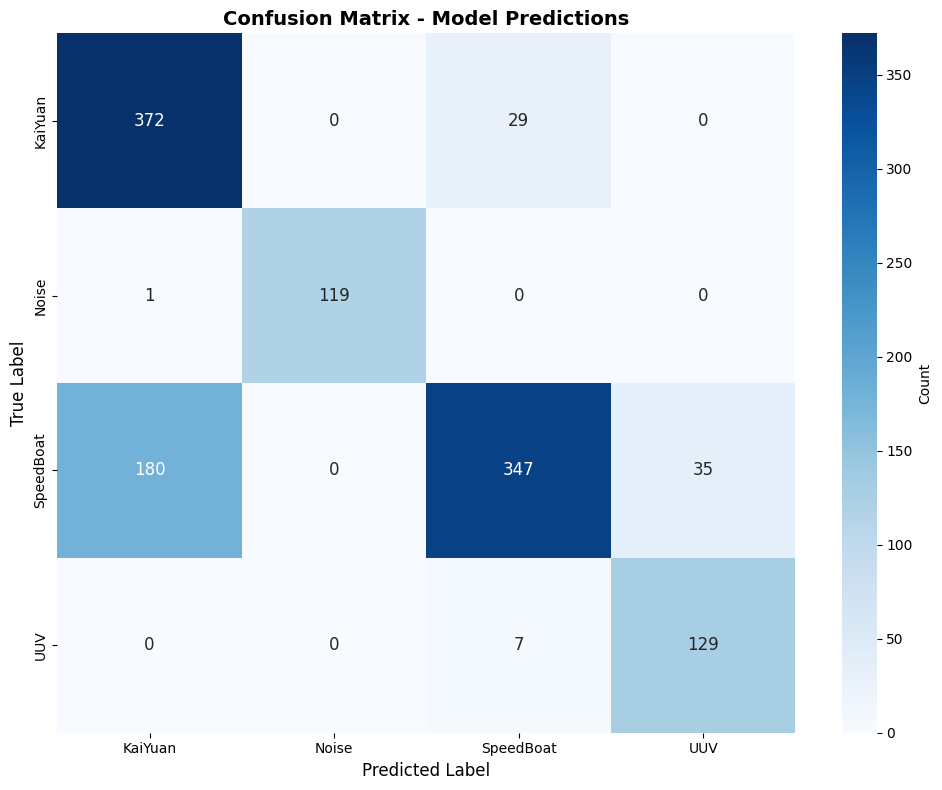

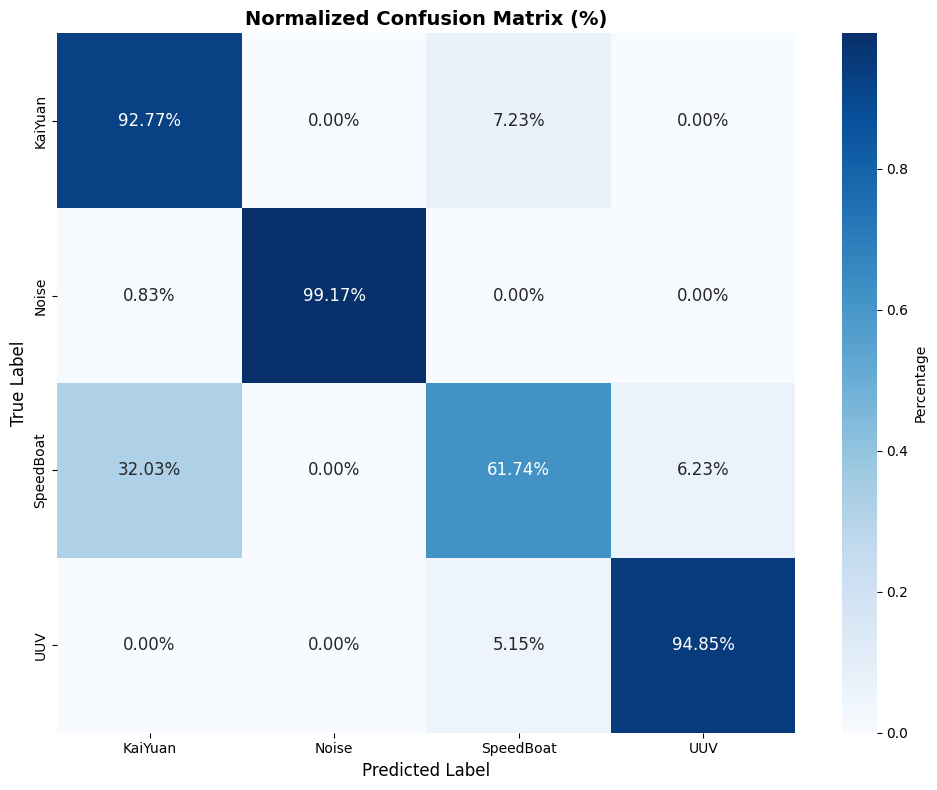


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     KaiYuan     0.6727    0.9277    0.7799       401
       Noise     1.0000    0.9917    0.9958       120
   SpeedBoat     0.9060    0.6174    0.7344       562
         UUV     0.7866    0.9485    0.8600       136

    accuracy                         0.7933      1219
   macro avg     0.8413    0.8713    0.8425      1219
weighted avg     0.8252    0.7933    0.7891      1219



In [8]:
import os
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# Define normalized transform (same as training)
transform_inference = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], 
    #                      std=[0.229, 0.224, 0.225])
])

model.eval()

class_names = ["KaiYuan", "Noise", "SpeedBoat","UUV"]  # adjust to YOUR classes

# Storage for all predictions and ground truth
all_predictions = []
all_ground_truth = []
per_class_metrics = {class_name: {'TP': 0, 'FP': 0, 'TN': 0, 'FN': 0} for class_name in class_names}

class_name_index = 0

for test_folder in MainFolderList:  # Loop through multiple test folders if needed

    # Initialize counters for each class
    class_counts = {class_name: 0 for class_name in class_names}
    
    # Get the true label from folder structure
    # Assuming folder structure is like: boatFullSpec_split_better/Test/1_spec
    true_label_name = os.path.basename(test_folder)  # e.g., "1_spec"
    
    # Map folder name to actual class name
    folder_to_class = {
        "1_spec": 0,  # KaiYuan
        "2_spec": 1,  # Noise
        "3_spec": 2,  # SpeedBoat
        "4_spec": 3   # UUV
    }
    
    true_class_idx = folder_to_class.get(true_label_name, class_name_index)
    true_label = class_names[true_class_idx]

    for file in os.listdir(test_folder):
        file_path = os.path.join(test_folder, file)

        # ✅ Skip non-image files
        if not file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")):
            continue

        try:
            # Load + preprocess with ImageNet normalization
            image = Image.open(file_path).convert("RGB")
            input_tensor = transform_inference(image).unsqueeze(0).to(device)

            # Inference
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = torch.softmax(outputs, dim=1)
                pred = torch.argmax(probs, dim=1)

            # Output
            predicted_label = class_names[pred.item()]
            predicted_idx = pred.item()
            confidence = probs.max().item()

            # Store for confusion matrix
            all_predictions.append(predicted_idx)
            all_ground_truth.append(true_class_idx)

            # Increment counter for this class
            class_counts[predicted_label] += 1
            
            # Update confusion matrix components for each class
            for idx, cls_name in enumerate(class_names):
                if predicted_idx == idx and true_class_idx == idx:
                    per_class_metrics[cls_name]['TP'] += 1
                elif predicted_idx == idx and true_class_idx != idx:
                    per_class_metrics[cls_name]['FP'] += 1
                elif predicted_idx != idx and true_class_idx == idx:
                    per_class_metrics[cls_name]['FN'] += 1
                else:
                    per_class_metrics[cls_name]['TN'] += 1

        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    # Print summary
    print("="*70)
    print(f"CLASS {class_names[true_class_idx].upper()} PREDICTION SUMMARY")
    print("="*70)
    for class_name, count in class_counts.items():
        print(f"{class_name}: {count}")
    print("Class Accuracy on Unseen Data:", class_counts[class_names[true_class_idx]] / sum(class_counts.values()) if sum(class_counts.values()) > 0 else 0)
    print("="*70)
    class_name_index += 1

# ================== COMPREHENSIVE METRICS ==================
print("\n" + "="*70)
print("COMPREHENSIVE METRICS FOR ALL CLASSES")
print("="*70)

# Convert to numpy arrays for confusion matrix
all_predictions = np.array(all_predictions)
all_ground_truth = np.array(all_ground_truth)

# Calculate confusion matrix
cm = confusion_matrix(all_ground_truth, all_predictions, labels=range(len(class_names)))

# Print detailed metrics for each class
print("\nPER-CLASS METRICS:")
print("-" * 70)

for idx, class_name in enumerate(class_names):
    TP = per_class_metrics[class_name]['TP']
    FP = per_class_metrics[class_name]['FP']
    TN = per_class_metrics[class_name]['TN']
    FN = per_class_metrics[class_name]['FN']
    
    # Calculate metrics
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # Also called Recall
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    recall = sensitivity  # Same as sensitivity
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{class_name.upper()}:")
    print(f"  Precision:   {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:      {recall:.4f} ({recall*100:.2f}%)")
    print(f"  Sensitivity: {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"  Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  F1-Score:    {f1_score:.4f}")
    print(f"  TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")

# Overall metrics using sklearn
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_ground_truth, all_predictions, average='weighted'
)

print("\n" + "-" * 70)
print("OVERALL METRICS:")
print(f"  Weighted Precision: {precision_weighted:.4f} ({precision_weighted*100:.2f}%)")
print(f"  Weighted Recall:    {recall_weighted:.4f} ({recall_weighted*100:.2f}%)")
print(f"  Weighted F1-Score:  {f1_weighted:.4f}")
print("-" * 70)

# ================== CONFUSION MATRIX VISUALIZATION ==================
print("\nConfusion Matrix:")
print(cm)

# Create a beautiful confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
plt.title('Confusion Matrix - Model Predictions', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'}, annot_kws={'size': 12})
plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(all_ground_truth, all_predictions, 
                          target_names=class_names, digits=4))

In [ ]:
# SAVE (after training)
torch.save(efficientnet_model.state_dict(), f'efficientnet_best.pth')



In [ ]:
print(f"Accuracy:    {metrics['accuracy']:.4f}")
print(f"Recall:      {metrics['recall_macro']:.4f}")
print(f"Sensitivity: {metrics['sensitivity_macro']:.4f}")
print(f"Specificity: {metrics['specificity_macro']:.4f}")

print("\nPer-class metrics:")
for i, class_name in enumerate(class_names):
    print(
        f"{class_name:10s} | "
        f"Sensitivity: {metrics['sensitivity_per_class'][i]:.4f} | "
        f"Specificity: {metrics['specificity_per_class'][i]:.4f}"
    )


## Transfer Learning: Freezing Backbone

When you freeze the backbone, only the classifier head learns. This is useful for:
- **Limited training data**: Backbone already learned good features
- **Faster training**: Fewer parameters to update
- **Better generalization**: Reduces overfitting on small datasets


In [ ]:
# # ========== UTILITY FUNCTION: Freeze/Unfreeze Layers ==========
# def freeze_backbone(model):
#     """
#     Freeze all parameters in the EfficientNet backbone.
#     Only the classifier head will be trained.
    
#     Parameters:
#         model: EfficientNet model with custom classifier
#     """
#     # Freeze the backbone (all layers except classifier)
#     for param in model.model.parameters():
#         param.requires_grad = False
    
#     # Unfreeze only the classifier (your custom head)
#     for param in model.model.classifier.parameters():
#         param.requires_grad = True
    
#     print("✅ Backbone frozen. Only classifier will train.")


# def unfreeze_backbone(model):
#     """
#     Unfreeze all parameters (train entire model).
#     Useful for fine-tuning after initial training.
    
#     Parameters:
#         model: EfficientNet model
#     """
#     for param in model.model.parameters():
#         param.requires_grad = True
    
#     print("✅ Backbone unfrozen. Entire model will train.")


# def count_trainable_params(model):
#     """
#     Count trainable vs frozen parameters.
    
#     Parameters:
#         model: PyTorch model
        
#     Returns:
#         Tuple of (trainable_count, total_count)
#     """
#     trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     total = sum(p.numel() for p in model.parameters())
#     frozen = total - trainable
    
#     print(f"Trainable parameters: {trainable:,}")
#     print(f"Frozen parameters:    {frozen:,}")
#     print(f"Total parameters:     {total:,}")
#     print(f"Training {100*trainable/total:.1f}% of model")
    
#     return trainable, total


In [ ]:
# ========== VARIANT 2: ENHANCED (With Freeze Option) ==========
class EfficientNetModel_V2_Frozen(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=True)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, num_classes)
        )
        
        if freeze_backbone:
            self._freeze_backbone()
    
    def _freeze_backbone(self):
        """Freeze all backbone layers, only train classifier."""
        for param in self.model.parameters():
            param.requires_grad = False
        
        # Unfreeze classifier
        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)


In [ ]:
# ========== EXAMPLE 1: FROZEN BACKBONE TRAINING ==========
# Initialize model with frozen backbone (default behavior)
model_frozen = EfficientNetModel_V2_Frozen(num_classes, freeze_backbone=True).to(device)

# Check parameter count
print("Model with FROZEN backbone:")
count_trainable_params(model_frozen)

# Create optimizer (will only optimize classifier params)
optimizer_frozen = optim.Adam(model_frozen.parameters(), lr=learning_rate)

# Train normally - only classifier weights will update
train_model(model_frozen, optimizer_frozen, train_loader, val_loader, num_epochs, "EfficientNet_V1_Frozen", num_classes)


In [ ]:
# ========== EXAMPLE 2: TWO-STAGE TRAINING (Frozen → Fine-tune) ==========
# Stage 1: Train with frozen backbone (fast, prevents overfitting)
print("\n" + "="*60)
print("STAGE 1: Training with FROZEN backbone")
print("="*60)

model_twostage = EfficientNetModel_V1_Frozen(num_classes, freeze_backbone=True).to(device)
optimizer_stage1 = optim.Adam(model_twostage.parameters(), lr=0.01)  # Can use higher LR for classifier

count_trainable_params(model_twostage)

# Train for initial epochs with frozen backbone
# train_model(model_twostage, optimizer_stage1, train_loader, val_loader, num_epochs=10, model_name="EfficientNet_Stage1_Frozen", num_classes=num_classes)

# Stage 2: Unfreeze and fine-tune entire model (lower learning rate!)
print("\n" + "="*60)
print("STAGE 2: Fine-tuning with UNFROZEN backbone")
print("="*60)

unfreeze_backbone(model_twostage)
count_trainable_params(model_twostage)

# Use lower learning rate for fine-tuning
optimizer_stage2 = optim.Adam(model_twostage.parameters(), lr=0.0001)  # Much lower!

# Train for remaining epochs with unfrozen backbone
# train_model(model_twostage, optimizer_stage2, train_loader, val_loader, num_epochs=20, model_name="EfficientNet_Stage2_Unfrozen", num_classes=num_classes)


## Training Strategy Comparison

### **Approach 1: Frozen Backbone (Recommended for small datasets)**
```
Train only classifier head (your added layers)
├─ ✅ Faster training
├─ ✅ Less memory required
├─ ✅ Better generalization on small datasets
├─ ✅ Prevents backbone from overfitting
└─ ❌ Less flexible, may underutilize model capacity
```

**When to use:**
- Limited training data (< 5,000 images)
- Time constraints
- Want maximum stability

### **Approach 2: Two-Stage Training (Recommended for larger datasets)**
```
Stage 1: Train with frozen backbone (5-10 epochs)
        └─ Fast initial learning

Stage 2: Unfreeze and fine-tune (lower LR, 15-20 epochs)
        └─ Adapt backbone to your specific task
```

**When to use:**
- Have sufficient training data (> 10,000 images)
- Want best accuracy
- Can afford longer training

### **Approach 3: Train Everything (Rarely recommended)**
```
Train all layers from start
├─ ❌ High risk of overfitting
├─ ❌ Requires careful hyperparameter tuning
├─ ❌ Much slower
└─ ✅ Maximum flexibility (if you have huge dataset)
```

### **Key Tips:**
- **Stage 1 LR**: Can be normal (0.001-0.01) since only classifier trains
- **Stage 2 LR**: Must be much lower (0.0001-0.00001) to avoid destroying learned features
- **Batch Normalization**: May need `model.eval()` during inference after unfreezing


In [ ]:
# ========== EXAMPLE 3: Freeze Existing Model (Any Model) ==========
# If you already have a model instantiated, freeze it manually:

# Create model WITHOUT freeze option
existing_model = EfficientNetModel_V1_Optimized(num_classes).to(device)

# Now freeze the backbone manually
freeze_backbone(existing_model)

# Check parameters
count_trainable_params(existing_model)

# Train with frozen backbone
# optimizer = optim.Adam(existing_model.parameters(), lr=learning_rate)
# train_model(existing_model, optimizer, train_loader, val_loader, num_epochs, "EfficientNet_V1_Manually_Frozen", num_classes)

# Later, if you want to unfreeze for fine-tuning:
# unfreeze_backbone(existing_model)
# new_optimizer = optim.Adam(existing_model.parameters(), lr=0.0001)
# train_model(existing_model, new_optimizer, train_loader, val_loader, num_epochs=10, model_name="EfficientNet_Unfrozen", num_classes=num_classes)
